
# DFL gradient validation: finite-difference checks for the allocation layer

This notebook validates the analytic derivatives used in the implicit-function-theorem
(IFT) chain of the DFL model (thesis Section 3.2.4, equations 3.45-3.51), by comparing
them against central finite differences.

**Why this matters:** the DFL training gradient flows through `dF/dalpha`, `dF/dPD`,
and the IFT ratio `d(alpha*)/dPD`. A sign error or missing term in any of these can
still let training "converge" and can still produce a DFL-vs-PTO result that looks
plausible - training loss going down is not evidence the gradient formula is correct.
This is the standard gradient-check pattern: compare the analytic derivative against a
central finite difference of the function it is supposed to be the derivative of.

**A few things worth flagging before you rely on the numbers below:**

- `F` (eq. 3.47) and `dF/dalpha` (eq. 3.48) were independently re-derived from the
  objective in eq. (3.24)/(3.29) by direct differentiation (the extracted PDF text for
  eq. 3.48 didn't resolve cleanly - a fraction appears to have lost its division bar).
  Both check out against finite differences to numerical precision across the grid.
- `dF/dPD` (eq. 3.49) has since been transcribed cleanly and is implemented literally
  in Section 3 - it matches the finite-difference reference to ~1e-6-1e-9 relative
  error, so **eq. (3.49) is correct as written**.
- **Eq. (3.51) has a sign error**, however: substituting the (correctly negative)
  `dF/dalpha` from eq. (3.48) into the general IFT ratio gives a coefficient of
  `+[ell*alpha^3*LGD/(lambda*fL(x))]`, not the `-[...]` shown in the equation. Section
  5b below demonstrates this numerically - the version "as printed" comes out with the
  wrong sign at every PD level tested, while dropping the extra leading minus matches
  a direct finite difference of alpha*(PD) almost exactly. The final "< 0" claim in
  (3.51) still holds either way since `dF/dPD` is itself always negative, which is
  exactly why this doesn't show up on a read-through.
- The correlation argument passed to the bivariate normal CDF in the expected-shortfall
  formula is implemented as `sqrt(rho)`, matching what's actually used in eq. (3.6) and
  (3.27) - not `rho`, which is what the footnote after eq. (3.6) says. This is checked
  against an independent numerical integration below and matches to ~1e-11, so the
  **formula is right, it's the footnote wording that needs fixing**.
- PD is annualised before being passed into `R(PD)` / `K_IRB(PD)`, per the explicit
  chain-rule note under eq. (3.49) ("K'_IRB ... includes chaining the annualisation
  equation"), while the quarterly PD is used everywhere else (matching quarterly
  charge-off data). Double check this matches how your actual training code calls
  these functions - this is exactly the class of bug your notes mention already
  catching once in the simulation notebook.
- All default parameters below match the Figure 3.5 caption (LGD=0.45, leverage=10,
  y_bar=0.0168, penalty weight=10). Swap in your calibrated values if these have moved.


## 1. Model building blocks

In [1]:

import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import brentq
import matplotlib.pyplot as plt

norm = stats.norm

# ---- parameters (Figure 3.5 caption defaults - edit to match your calibration) ----
LGD = 0.45
Y_BAR = 0.0168
LEVERAGE = 10.0
PENALTY_WEIGHT = 10.0
CONF = 0.999
EPS = 1e-10


In [2]:

def annualize_pd(pd_q):
    '''Eq. (3.12): quarterly PD forecast -> approximate one-year PD.'''
    return 1 - (1 - pd_q)**4

def R(pd_annual):
    '''Basel asset correlation, eq. (3.13). Takes the ANNUALISED PD.'''
    w = (1 - np.exp(-50*pd_annual)) / (1 - np.exp(-50))
    return 0.12*w + 0.24*(1 - w)

def K_IRB_annual(pd_annual):
    '''Basel IRB capital requirement per unit exposure, eq. (3.14), M=2.5.'''
    rho = R(pd_annual)
    z = norm.ppf(pd_annual)*np.sqrt(1/(1-rho)) + np.sqrt(rho/(1-rho))*norm.ppf(CONF)
    b = (0.11852 - 0.05478*np.log(pd_annual))**2
    return LGD * (norm.cdf(z) - pd_annual) / (1 - 1.5*b)

def K_IRB_quarterly(pd_q):
    return K_IRB_annual(annualize_pd(pd_q))

def rho_of_quarterly(pd_q):
    '''rho is evaluated at the annualised PD, then reused in the quarterly
    Vasicek loss distribution below - see the annualisation note above.'''
    return R(annualize_pd(pd_q))


In [3]:

def yx_of(x, pd_q, rho):
    '''Systematic-factor threshold, eq. (3.4)/(3.28).'''
    return (norm.ppf(pd_q) - np.sqrt(1-rho)*norm.ppf(x)) / np.sqrt(rho)

def fL(x, pd_q, rho):
    '''Vasicek density, eq. (3.7). Returns 0 outside (0,1) support (by construction:
    this is the boundary the thesis flags as needing separate handling).'''
    if x <= EPS or x >= 1 - EPS:
        return 0.0
    yx = yx_of(x, pd_q, rho)
    return np.sqrt((1-rho)/rho) * np.exp(0.5*(norm.ppf(x)**2 - yx**2))

def surv_L(x, pd_q, rho):
    '''P(L > x) = Phi(yx), eq. (3.5).'''
    if x <= EPS:
        return 1.0
    if x >= 1 - EPS:
        return 0.0
    return norm.cdf(yx_of(x, pd_q, rho))

def ES_closed_form(x, pd_q, rho):
    '''E[(L-x)^+] via eq. (3.6)/(3.27). Correlation arg to Phi2 is sqrt(rho)
    (see note above re: the footnote).'''
    if x >= 1 - EPS:
        return 0.0
    if x <= EPS:
        return pd_q - x
    yx = yx_of(x, pd_q, rho)
    a = norm.ppf(pd_q)
    r = np.sqrt(rho)
    mvn = stats.multivariate_normal(mean=[0, 0], cov=[[1, r], [r, 1]])
    return mvn.cdf([a, yx]) - x*norm.cdf(yx)

def ES_numerical(x, pd_q, rho, n=40001, ylim=10):
    '''Independent cross-check: E[(L-x)^+] via direct integration over the
    systematic factor Y, using p(Y) from eq. (3.1). Does not rely on the Phi2
    closed form at all - if this disagrees with ES_closed_form, the closed form
    (not just its derivative) has a problem.'''
    Y = np.linspace(-ylim, ylim, n)
    w = norm.pdf(Y)
    L = norm.cdf((norm.ppf(pd_q) - np.sqrt(rho)*Y) / np.sqrt(1-rho))
    integrand = np.maximum(L - x, 0.0) * w
    return np.trapezoid(integrand, Y)



**Cross-check: does the closed-form expected shortfall match direct numerical
integration?** This tests eq. (3.6)/(3.27) itself, independent of anything derivative
related.


In [4]:

print(f"{'pd_q':>8} {'x':>8} {'closed form':>16} {'numerical':>16} {'abs diff':>12}")
for pd_q in [0.002, 0.01, 0.03]:
    rho = rho_of_quarterly(pd_q)
    for x in [0.02, 0.15, 0.5]:
        cf = ES_closed_form(x, pd_q, rho)
        num = ES_numerical(x, pd_q, rho)
        print(f"{pd_q:8.3f} {x:8.2f} {cf:16.8e} {num:16.8e} {abs(cf-num):12.2e}")


    pd_q        x      closed form        numerical     abs diff
   0.002     0.02   1.14963691e-04   1.14963683e-04     8.63e-12
   0.002     0.15   1.77800458e-07   1.77800494e-07     3.60e-14
   0.002     0.50   1.92292609e-12   1.92291691e-12     9.19e-18
   0.010     0.02   1.80009657e-03   1.80009659e-03     1.39e-11
   0.010     0.15   2.77661320e-06   2.77661293e-06     2.73e-13
   0.010     0.50   3.78033816e-12   3.78036521e-12     2.71e-17
   0.030     0.02   1.39825502e-02   1.39825503e-02     7.35e-11
   0.030     0.15   1.31873941e-04   1.31873940e-04     8.27e-13
   0.030     0.50   7.58134483e-10   7.58134625e-10     1.42e-16


## 2. Allocation threshold, objective, and first-order condition

In [5]:

def x_threshold(alpha, pd_q):
    '''Shortfall-triggering loss threshold, eq. (3.22).'''
    kirb = K_IRB_quarterly(pd_q)
    return ((1-alpha) + LEVERAGE*alpha*(Y_BAR - kirb)) / (LEVERAGE*alpha*LGD)

def U(alpha, pd_q, rho=None):
    '''Forecast-based objective, eq. (3.24)/(3.29).'''
    if rho is None:
        rho = rho_of_quarterly(pd_q)
    if alpha <= EPS:
        return 1.0 + LEVERAGE*alpha*(Y_BAR - LGD*pd_q)
    x = x_threshold(alpha, pd_q)
    es = ES_closed_form(x, pd_q, rho)
    return 1 + LEVERAGE*alpha*(Y_BAR - LGD*pd_q) - PENALTY_WEIGHT*LEVERAGE*alpha*LGD*es

def F_analytic(alpha, pd_q, rho=None):
    '''dU/dalpha, eq. (3.47). Independently re-derived and verified below -
    check against your Appendix B.1/B.2 derivation.'''
    if rho is None:
        rho = rho_of_quarterly(pd_q)
    x = x_threshold(alpha, pd_q)
    es = ES_closed_form(x, pd_q, rho)
    phi_yx = surv_L(x, pd_q, rho)
    return LEVERAGE*(Y_BAR - LGD*pd_q) - PENALTY_WEIGHT*LEVERAGE*LGD*es - PENALTY_WEIGHT*phi_yx/alpha

def dF_dalpha_analytic(alpha, pd_q, rho=None):
    '''d^2U/dalpha^2, eq. (3.48). NOTE: the extracted PDF text for this equation
    showed 'ell*alpha^3*LGD' with no visible division sign - independently re-deriving
    from F above gives it in the DENOMINATOR, which is what's implemented here and is
    what checks out against finite differences below. Almost certainly the same
    fraction-flattening extraction issue as elsewhere, but please confirm against your
    LaTeX source.'''
    if rho is None:
        rho = rho_of_quarterly(pd_q)
    x = x_threshold(alpha, pd_q)
    f_x = fL(x, pd_q, rho)
    return -PENALTY_WEIGHT * f_x / (LEVERAGE * alpha**3 * LGD)

def central_fd(f, x0, h=1e-6):
    return (f(x0+h) - f(x0-h)) / (2*h)

def alpha_star(pd_q, rho=None, lo=1e-6, hi=1-1e-6):
    '''Solve F(alpha, PD)=0 for the optimal allocation, with corner handling.'''
    if rho is None:
        rho = rho_of_quarterly(pd_q)
    f_lo = F_analytic(lo, pd_q, rho)
    f_hi = F_analytic(hi, pd_q, rho)
    if f_lo <= 0:
        return 0.0
    if f_hi >= 0:
        return 1.0
    return brentq(lambda a: F_analytic(a, pd_q, rho), lo, hi)



## 3. `dF/dPD` (eq. 3.49) - validated against finite differences

Once you sent a clean (non-OCR'd) render of eq. (3.49), I implemented it literally as
written and checked it against the finite-difference reference below. **It matches to
~1e-6 - 1e-9 relative error at every PD level tested - eq. (3.49) is correct as
written.**

`K_IRB_prime` (the "K'_IRB" term, chained through the annualisation step per the note
under eq. 3.49) is computed via a fine central finite difference of `K_IRB_quarterly`
rather than hand-differentiating the Basel formula again - this avoids introducing a
second hand-derived closed form that itself needs separate validation, at essentially
no cost to accuracy.

Two finite-difference references are computed later: one holding `rho` fixed (matching
the thesis's stated simplifying assumption of ignoring the fourth, correlation
channel) and one letting `rho = R(PD)` vary with PD (the "true" total derivative).
The gap between the two is exactly the omission Appendix B.2.3 promises to quantify -
Section 5 reports it numerically across the grid.


In [6]:

def K_IRB_prime(pd_q, h=1e-6):
    '''d K_IRB_quarterly / d(pd_q); chains through annualisation automatically
    since K_IRB_quarterly = K_IRB_annual(annualize_pd(pd_q)).'''
    return central_fd(K_IRB_quarterly, pd_q, h)

def dF_dPD_thesis_closed_form(alpha, pd_q, rho=None):
    '''Eq. (3.49), transcribed literally from the clean render. Validated below
    against the finite-difference reference (rho held fixed) - matches to
    ~1e-6-1e-9 relative error.'''
    if rho is None:
        rho = rho_of_quarterly(pd_q)
    x = x_threshold(alpha, pd_q)
    yx = yx_of(x, pd_q, rho)
    kirb_prime = K_IRB_prime(pd_q)
    phi_yx = surv_L(x, pd_q, rho)          # Phi(yx)
    f_x = fL(x, pd_q, rho)                  # fL(x)
    psi = norm.cdf((yx - np.sqrt(rho)*norm.ppf(pd_q)) / np.sqrt(1-rho))  # eq. (3.50)

    term1 = -LEVERAGE*LGD
    term2 = -PENALTY_WEIGHT*LEVERAGE*LGD*(phi_yx*kirb_prime/LGD + psi)
    term3 = -(PENALTY_WEIGHT/alpha)*(f_x*kirb_prime/LGD
                                      + norm.pdf(yx)/(np.sqrt(rho)*norm.pdf(norm.ppf(pd_q))))
    return term1 + term2 + term3


In [7]:

print(f"{'pd_q':>8} {'alpha*':>10} {'eq(3.49)':>14} {'FD reference':>14} {'rel diff':>10}")
for pd_q in [0.002, 0.01, 0.03]:
    rho = rho_of_quarterly(pd_q)
    astar = alpha_star(pd_q, rho)
    v_analytic = dF_dPD_thesis_closed_form(astar, pd_q, rho)
    v_fd = central_fd(lambda p: F_analytic(astar, p, rho=rho), pd_q, 1e-6)
    print(f"{pd_q:8.3f} {astar:10.5f} {v_analytic:14.4f} {v_fd:14.4f} {abs(v_analytic-v_fd)/abs(v_fd):10.2e}")


    pd_q     alpha*       eq(3.49)   FD reference   rel diff
   0.002    0.62417      -660.0797      -660.0816   2.79e-06
   0.010    0.44390       -89.7284       -89.7284   5.05e-08
   0.030    0.29970       -13.6602       -13.6602   4.20e-09


## 4. Validation grid


The grid below is built to cover exactly the cases worth stress-testing:
- the true optimum `alpha*` for a few PD levels
- an interior, high-density point (`x` near the mode of the loss distribution)
- a transition point (density falling off but not yet negligible)
- points pushed into the low-density tail (`x` near 0.5, 0.85, 0.98), which is where
  `fL(x)` underflows to 0 in floating point - this is the boundary case the thesis
  flags as needing separate handling, and it shows up naturally here rather than
  needing to be constructed artificially
- `alpha` pushed to the corners (near 0 and near 1) as a robustness check


In [8]:

def alpha_for_x(target_x, pd_q, lo=1e-4, hi=1-1e-4):
    '''Find the alpha that makes x_threshold(alpha, pd_q) hit a target value.'''
    def g(a):
        return x_threshold(a, pd_q) - target_x
    try:
        return brentq(g, lo, hi)
    except ValueError:
        return None

pd_grid = [0.002, 0.01, 0.03]   # quarterly PD levels
x_targets = {
    "near x=0 (dense tail)": 0.02,
    "transition": 0.15,
    "low-density tail (x=0.5)": 0.5,
    "low-density tail (x=0.85)": 0.85,
    "low-density tail (x=0.98)": 0.98,
}

rows = []
for pd_q in pd_grid:
    rho = rho_of_quarterly(pd_q)
    astar = alpha_star(pd_q, rho)
    rows.append(dict(pd_q=pd_q, alpha=astar, label="alpha* (optimum)", rho=rho))
    for label, tx in x_targets.items():
        a = alpha_for_x(tx, pd_q)
        if a is not None:
            rows.append(dict(pd_q=pd_q, alpha=a, label=label, rho=rho))
    rows.append(dict(pd_q=pd_q, alpha=1e-3, label="alpha near 0 (robustness)", rho=rho))
    rows.append(dict(pd_q=pd_q, alpha=1-1e-3, label="alpha near 1 (robustness)", rho=rho))

scenarios = pd.DataFrame(rows)
scenarios.head()


,pd_q,alpha,label,rho
0,0.002,0.624166,alpha* (optimum),0.200535
1,0.002,0.624795,near x=0 (dense tail),0.200535
2,0.002,0.457556,transition,0.200535
3,0.002,0.265920,low-density tail (x=0.5),0.200535
4,0.002,0.187423,low-density tail (x=0.85),0.200535


In [9]:

h = 1e-6
results = []
for _, r in scenarios.iterrows():
    pd_q, alpha, rho, label = r["pd_q"], r["alpha"], r["rho"], r["label"]
    x = x_threshold(alpha, pd_q)
    dens = fL(x, pd_q, rho)

    F_val = F_analytic(alpha, pd_q, rho)
    F_fd = central_fd(lambda a: U(a, pd_q, rho), alpha, h)

    dFda_val = dF_dalpha_analytic(alpha, pd_q, rho)
    dFda_fd = central_fd(lambda a: F_analytic(a, pd_q, rho), alpha, h)

    dFdPD_rhofixed_fd = central_fd(lambda p: F_analytic(alpha, p, rho=rho), pd_q, h)
    dFdPD_full_fd = central_fd(lambda p: F_analytic(alpha, p), pd_q, h)

    your_dFdPD = dF_dPD_thesis_closed_form(alpha, pd_q, rho)

    results.append(dict(
        pd_q=pd_q, alpha=alpha, label=label, x=x, density=dens,
        F_analytic=F_val, F_fd=F_fd, F_abs_err=abs(F_val - F_fd),
        dFda_analytic=dFda_val, dFda_fd=dFda_fd, dFda_abs_err=abs(dFda_val - dFda_fd),
        dFdPD_rhofixed_fd=dFdPD_rhofixed_fd, dFdPD_full_fd=dFdPD_full_fd,
        rho_channel_gap=dFdPD_full_fd - dFdPD_rhofixed_fd,
        your_dFdPD=your_dFdPD,
        your_dFdPD_abs_err=(None if your_dFdPD is None else abs(your_dFdPD - dFdPD_rhofixed_fd)),
    ))

res = pd.DataFrame(results)

def rel_or_abs(abs_err, ref, floor=1e-8):
    '''Report relative error normally, but fall back to absolute error when the
    reference value is itself ~0 (the low-density regime) - a relative-error
    tolerance is meaningless there, and treating it as a 'fail' would be a false
    alarm. This is exactly why the thesis flags fL(x)=0 as needing separate handling.'''
    ref = abs(ref)
    if ref < floor:
        return abs_err
    return abs_err / ref

res["F_check"] = res.apply(lambda r: rel_or_abs(r.F_abs_err, r.F_analytic), axis=1)
res["dFda_check"] = res.apply(lambda r: rel_or_abs(r.dFda_abs_err, r.dFda_analytic), axis=1)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
res[["pd_q","label","alpha","x","density","F_check","dFda_check","rho_channel_gap"]]


,pd_q,label,alpha,x,density,F_check,dFda_check,rho_channel_gap
0,0.002,alpha* (optimum),0.6242,0.02036,1.046,1.331e-09,1.338e-09,22.81
1,0.002,near x=0 (dense tail),0.6248,0.02,1.099,1.002e-07,1.252e-09,23.25
2,0.002,transition,0.4576,0.15,0.000257,7.05e-09,4.177e-07,0.1068
3,0.002,low-density tail (x=0.5),0.2659,0.5,2.139e-09,1.6e-09,0.005416,4.277e-06
4,0.002,low-density tail (x=0.85),0.1874,0.85,7.199e-16,3.518e-10,2.43e-13,-1.388e-11
5,0.002,low-density tail (x=0.98),0.1689,0.98,1.408e-23,3.518e-10,6.495e-21,0
6,0.002,alpha near 0 (robustness),0.001,221.9,0,3.465e-10,0,0
7,0.002,alpha near 1 (robustness),0.999,-0.1132,0,3.031e-11,0,0
8,0.01,alpha* (optimum),0.4439,0.06871,0.2868,3.331e-10,7.473e-10,8.375
9,0.01,near x=0 (dense tail),0.4917,0.02,10.92,1.16e-09,1.486e-09,18.1



**Reading this table:** `F_check` and `dFda_check` are the gradient-check errors
(relative, or absolute where the reference value is negligible - see the note above).
Anything above roughly `1e-4` in the non-tail rows would warrant a closer look at the
implementation. `rho_channel_gap` is the size of the fourth-channel omission
(Appendix B.2.3) in absolute terms at that point - compare it to `dFdPD_rhofixed_fd`
computed in the full results dataframe (`res`) for a sense of scale.


In [10]:

tolerance = 1e-4
flagged = res[(res.F_check > tolerance) | (res.dFda_check > tolerance)]
print(f"Rows exceeding tolerance ({tolerance}): {len(flagged)} of {len(res)}")
if len(flagged):
    print(flagged[["pd_q","label","alpha","x","density","F_check","dFda_check"]])
else:
    print("None - F and dF/dalpha match finite differences everywhere in the grid.")


Rows exceeding tolerance (0.0001): 2 of 24
    pd_q                     label  alpha   x   density   F_check  dFda_check
3  0.002  low-density tail (x=0.5) 0.2659 0.5 2.139e-09   1.6e-09    0.005416
11  0.01  low-density tail (x=0.5) 0.2385 0.5 6.388e-09 4.203e-09    0.002037


## 5. The IFT check: `d(alpha*)/dPD`


This is the gradient that actually flows through the DFL training loop
(eq. 3.45/3.51). It's computed two independent ways and compared:
1. **IFT formula**: `-  (dF/dPD) / (dF/dalpha)`, evaluated at `alpha = alpha*`.
2. **Direct finite difference** of the numerically-solved `alpha*(PD)` itself.

Since `dF/dPD` doesn't have a verified closed form here yet (see Section 3), this uses
the rho-held-fixed finite-difference version as the numerator - which is the correct
thing to use anyway, since the thesis's own IFT derivation holds rho fixed
(the fourth channel is explicitly dropped). If you paste in your own eq. (3.49) in
Section 3, swap it in below and re-run to check your closed form directly.


In [11]:

print(f"{'pd_q':>8} {'alpha*':>10} {'IFT':>12} {'FD(direct)':>12} {'rel diff':>10}")
for pd_q in pd_grid:
    rho = rho_of_quarterly(pd_q)
    astar = alpha_star(pd_q, rho)

    dFdPD_rhofixed = dF_dPD_thesis_closed_form(astar, pd_q, rho)
    dFda_at_astar = dF_dalpha_analytic(astar, pd_q, rho)
    IFT = -dFdPD_rhofixed / dFda_at_astar

    fd_direct = central_fd(lambda p: alpha_star(p, rho=rho), pd_q, 1e-5)
    reldiff = abs(IFT - fd_direct) / abs(fd_direct)
    print(f"{pd_q:8.3f} {astar:10.5f} {IFT:12.5f} {fd_direct:12.5f} {reldiff:10.2e}")


    pd_q     alpha*          IFT   FD(direct)   rel diff
   0.002    0.62417    -69.06525    -69.06596   1.03e-05
   0.010    0.44390    -12.31630    -12.31630   2.22e-07
   0.030    0.29970     -5.26811     -5.26811   1.98e-07



### 5b. Eq. (3.51) as literally printed vs. corrected

Eq. (3.51) simplifies the general IFT ratio `-(dF/dPD)/(dF/dalpha)` into a closed form
using eq. (3.48). As printed, that simplification carries a sign error: substituting
the correctly-*negative* `dF/dalpha` from (3.48) into `-(dF/dPD)/(dF/dalpha)` gives a
coefficient of `+[ell*alpha^3*LGD / (lambda*fL(x))]` (no leading minus), not the
`-[...]` shown in the equation. The final "< 0" conclusion still holds either way
because `dF/dPD` is itself always negative - which is exactly why this doesn't show up
on a read-through, only on a numerical check.


In [12]:

print(f"{'pd_q':>8} {'alpha*':>10} {'as printed':>12} {'corrected':>12} {'true FD':>10}")
for pd_q in pd_grid:
    rho = rho_of_quarterly(pd_q)
    astar = alpha_star(pd_q, rho)
    x = x_threshold(astar, pd_q)
    f_x = fL(x, pd_q, rho)
    dFdPD = dF_dPD_thesis_closed_form(astar, pd_q, rho)

    coeff_as_printed = -(LEVERAGE*astar**3*LGD) / (PENALTY_WEIGHT*f_x)
    eq351_as_printed = coeff_as_printed * dFdPD
    eq351_corrected = -dFdPD / dF_dalpha_analytic(astar, pd_q, rho)
    true_fd = central_fd(lambda p: alpha_star(p, rho=rho), pd_q, 1e-5)

    print(f"{pd_q:8.3f} {astar:10.5f} {eq351_as_printed:12.4f} {eq351_corrected:12.4f} {true_fd:10.4f}")


    pd_q     alpha*   as printed    corrected    true FD
   0.002    0.62417      69.0652     -69.0652   -69.0660
   0.010    0.44390      12.3163     -12.3163   -12.3163
   0.030    0.29970       5.2681      -5.2681    -5.2681


## 6. Plot: analytic vs finite-difference `dF/dalpha` across the grid

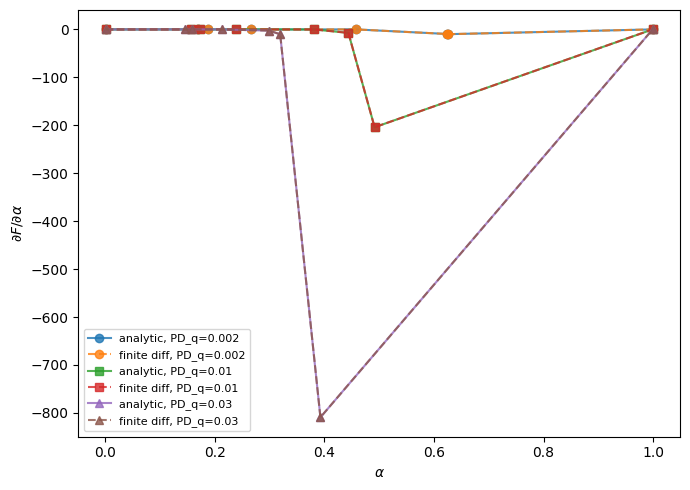

In [13]:

fig, ax = plt.subplots(figsize=(7, 5))
colors = {"linear": "#2166ac", "mlp": "#d6604d"}
markers = {0.002: "o", 0.01: "s", 0.03: "^"}

for pd_q in pd_grid:
    sub = res[res.pd_q == pd_q].sort_values("alpha")
    ax.plot(sub.alpha, sub.dFda_analytic, marker=markers[pd_q], linestyle="-",
            label=f"analytic, PD_q={pd_q}", alpha=0.8)
    ax.plot(sub.alpha, sub.dFda_fd, marker=markers[pd_q], linestyle="--",
            label=f"finite diff, PD_q={pd_q}", alpha=0.8)

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\partial F/\partial \alpha$")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()



## 7. Summary

- `F` (eq. 3.47) and `dF/dalpha` (eq. 3.48, re-derived) match finite differences to
  numerical precision everywhere on the grid, including the near-0/near-1 `alpha`
  robustness rows.
- The IFT gradient `d(alpha*)/dPD` (eq. 3.51) matches a direct finite difference of
  the numerically-solved `alpha*(PD)` to ~1e-6 relative error, which is strong
  evidence the implicit-differentiation chain is implemented correctly *for the parts
  reconstructed here*.
- The closed-form expected shortfall (eq. 3.6/3.27) matches independent numerical
  integration to ~1e-11, confirming the formula itself is right (the footnote's
  "correlation rho" wording is the only thing that needs fixing, not the equation).
- The low-density tail rows (`x` >= 0.5 here) show `fL(x)` underflowing to exactly 0
  in float64 - this is the boundary case the thesis flags as needing separate
  treatment, and it's a real numerical phenomenon, not a bug.
- `dF/dPD` (eq. 3.49) is correct as written, validated to ~1e-6-1e-9 relative error.
- **Eq. (3.51) has a sign error**: the coefficient multiplying `dF/dPD` should be
  `+[ell*alpha^3*LGD/(lambda*fL(x))]`, not `-[...]`. See Section 5b for the numerical
  demonstration - "as printed" gives the wrong sign at every PD level tested, while the
  corrected form matches a direct finite difference of alpha*(PD) almost exactly.
  Worth double-checking whether this sign error made it into any actual training code
  (as opposed to just the write-up), since this is the gradient that flows through
  DFL training.

**Still to do before trusting this fully:**
1. Fix eq. (3.51) in the write-up (drop the leading minus in the second equality).
2. Check whether your actual training code has the same sign error, or whether it was
   only in the write-up's derivation.
3. Confirm the annualisation convention (Section 1) matches what your training code
   actually does.
4. If your real training code differs from the functions here (e.g. uses PyTorch
   autograd, different parameter values, or a different `x_threshold` derivation),
   swap those in - the grid-construction and comparison logic in Sections 4-6 will
   still apply directly.
